In [2]:
# Kiểm định Chiến lược Tối ưu hóa Danh mục (Backtesting Portfolio Strategies).

# Mục tiêu: So sánh hiệu suất (Out-of-sample) của 4 chiến lược:


# Benchmark 1: Naive 1/N (Phân bổ đều).


# Benchmark 2: Static Markowitz (Mean-Variance truyền thống).


# Strategy: Regime-based Dynamic MSM (Chiến lược đề xuất: Bull -> Max Sharpe, Bear -> Cash Out).
#Regime-based Dynamic MA

# Tham số Backtest:

# Window size: 90 ngày (3 tháng).

# Rebalancing: Hàng tuần (Weekly).

# Transaction Cost: 0.1%.

In [3]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf


In [4]:
import os

current_dir = os.getcwd()
print(current_dir)
os.chdir("..")
print(os.getcwd())


/Users/giangluong/Desktop/MasterDS/Thesis/LuongThiGiang_Thesis_Code/notebooks
/Users/giangluong/Desktop/MasterDS/Thesis/LuongThiGiang_Thesis_Code


In [5]:
#Load df_returns, df_regime và thêm synthetic USDT (risk-free)

DATA_DIR = Path("data/processed")

returns_file = DATA_DIR / "log_returns_1d.csv"
regime_file = DATA_DIR / "btc_regimes.csv"

# 1) Load returns (altcoins + có thể cả BTC)
df_returns = pd.read_csv(returns_file, parse_dates=["date"])
df_returns = df_returns.set_index("date").sort_index()

# 1.1. Thêm tài sản USDT (risk-free)
# Giả sử lãi suất phi rủi ro = 2%/năm
rf_daily = 0.02 / 365  # daily simple return xấp xỉ

df_returns_with_cash = df_returns.copy()
df_returns_with_cash["USDT"] = rf_daily  # biến động = 0, lợi nhuận = const mỗi ngày

# 2) Load regime từ btc_regimes.csv
df_regime = pd.read_csv(regime_file, parse_dates=["date"])
df_regime = df_regime.set_index("date").sort_index()
# Giá đóng cửa BTC đã có sẵn 
df_prices = pd.DataFrame(index=df_regime.index)
df_prices["BTC"] = df_regime["BTC_Price"]

df_ma = pd.DataFrame(index=df_regime.index)
df_ma["MA_50"] = df_prices["BTC"].rolling(window=50).mean()

# Đảm bảo có cả Regime_Combined và Regime_MA
df_regime = df_regime[["Regime_Combined", "Regime_MA"]]

# 3) Align theo index chung
df_all = df_returns_with_cash.join(df_regime, how="inner")

# Drop ngày không có regime
df_all = df_all.dropna(subset=["Regime_Combined", "Regime_MA"])

# Asset dùng để đầu tư (bao gồm cả USDT)
asset_cols = list(df_returns_with_cash.columns)  # altcoins + USDT

returns = df_all[asset_cols]
regimes_combined = df_all["Regime_Combined"].astype(int)
regimes_ma = df_all["Regime_MA"].astype(int)

print("Shape returns:", returns.shape)
print("Số ngày:", len(returns))
print("Assets:", asset_cols)
returns.head()


Shape returns: (1834, 21)
Số ngày: 1834
Assets: ['ADA_USDT', 'ATOM_USDT', 'AVAX_USDT', 'BCH_USDT', 'BNB_USDT', 'BTC_USDT', 'DOGE_USDT', 'DOT_USDT', 'EOS_USDT', 'ETC_USDT', 'ETH_USDT', 'LINK_USDT', 'LTC_USDT', 'NEO_USDT', 'SOL_USDT', 'TRX_USDT', 'UNI_USDT', 'XLM_USDT', 'XRP_USDT', 'XTZ_USDT', 'USDT']


,ADA_USDT,ATOM_USDT,AVAX_USDT,BCH_USDT,BNB_USDT,BTC_USDT,DOGE_USDT,DOT_USDT,EOS_USDT,ETC_USDT,...,LINK_USDT,LTC_USDT,NEO_USDT,SOL_USDT,TRX_USDT,UNI_USDT,XLM_USDT,XRP_USDT,XTZ_USDT,USDT
date,,,,,,,,,,,,,,,,,,,,,
2020-09-23 00:00:00+00:00,-0.061123,-0.092251,-0.408628,-0.056597,-0.051791,-0.027747,-0.038095,-0.037898,-0.051666,-0.022412,...,-0.134995,-0.034545,-0.026073,-0.018533,-0.005216,0.113383,-0.061427,-0.050070,-0.075891,0.000055
2020-09-24 00:00:00+00:00,0.074294,0.155081,0.272238,0.038903,0.073498,0.047188,0.032975,0.088420,0.036740,0.027152,...,0.256574,0.044614,0.102649,0.096271,0.054406,0.164663,0.043974,0.048953,0.098414,0.000055
2020-09-25 00:00:00+00:00,0.160706,0.066447,0.015458,0.001387,0.004786,-0.004635,0.026937,0.008121,0.004253,0.001689,...,0.083348,0.024193,-0.023283,0.015907,0.033343,-0.049521,0.058459,0.037027,0.025109,0.000055
2020-09-26 00:00:00+00:00,-0.015177,-0.039162,-0.041898,0.021927,0.059256,0.003916,-0.001593,-0.019006,0.008219,0.074488,...,-0.039064,0.000217,-0.014510,-0.020563,0.001473,-0.009425,-0.011042,-0.000041,-0.018219,0.000055
2020-09-27 00:00:00+00:00,0.059274,0.025714,0.028011,0.035552,0.001952,0.004246,-0.000668,-0.008021,0.009389,0.015158,...,0.045198,0.000434,0.006785,0.009258,-0.021946,-0.004653,-0.006794,0.007466,0.003129,0.000055


In [6]:
# Optimization engine (MinVar, MaxSharpe) + LedoitWolf shrinkage

def shrink_cov(data_values):
    """
    data_values: ndarray shape (n_samples, n_assets)
    Return: shrinked covariance matrix (Ledoit-Wolf)
    """
    lw = LedoitWolf().fit(data_values)
    return lw.covariance_



def optimize_max_sharpe(expected_returns, cov_matrix, risk_free_rate=0.0):
    """
    Max Sharpe Ratio portfolio (không short, sum w = 1)
    expected_returns: array shape (n,)
    cov_matrix: (n, n)
    """
    n = len(expected_returns)
    initial_weights = np.ones(n) / n

    def neg_sharpe(w):
        p_ret = np.dot(w, expected_returns)
        p_vol = np.sqrt(np.dot(w.T, np.dot(cov_matrix, w)))
        if p_vol == 0:
            return 0.0
        return - (p_ret - risk_free_rate) / p_vol

    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    bounds = tuple((0.0, 1.0) for _ in range(n))

    result = minimize(
        neg_sharpe,
        initial_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )
    if not result.success:
        return np.ones(n) / n
    return result.x


In [7]:
# Walk-forward backtest với
# 1) EqualWeight
# 2) Static Markowitz
# 3) RegimeDynamic_Combined
# 4) RegimeDynamic_MA

WINDOW_SIZE = 90   
STEP_DAYS = 7       # tái cân bằng hàng tuần
TC_RATE = 0.001     # 0.1% transaction cost

dates = returns.index
n_days = len(dates)
n_assets = len(asset_cols)

# Index của USDT
if "USDT" not in asset_cols:
    raise ValueError("Không tìm thấy tài sản USDT trong asset_cols")
usdt_idx = asset_cols.index("USDT")

# Benchmark 1: 1/N (bao gồm cả USDT)
w_equal = np.ones(n_assets) / n_assets
port_ret_equal = (returns.values @ w_equal)

# Khởi tạo arrays cho 3 chiến lược còn lại
port_ret_static = np.full(n_days, np.nan)
port_ret_regime_combined = np.full(n_days, np.nan)
port_ret_regime_ma = np.full(n_days, np.nan)  

# Lưu lịch sử weights để vẽ
weights_static_hist = []
weights_regime_combined_hist = []
weights_regime_ma_hist = []
rebalance_dates = []

prev_w_static = None
prev_w_regime_combined = None
prev_w_regime_ma = None

df_regime_combined = df_regime["Regime_Combined"]

for start_idx in range(WINDOW_SIZE, n_days - 1, STEP_DAYS):
    current_date = dates[start_idx]
    rebalance_date = current_date

    window_slice = slice(start_idx - WINDOW_SIZE, start_idx)
    window_returns = returns.iloc[window_slice]

    # === Static Markowitz dùng toàn bộ cửa sổ ===
    mu_window = window_returns.mean().values
    cov_window = shrink_cov(window_returns.values)

    w_static = optimize_max_sharpe(mu_window, cov_window)

    # ==== RegimeDynamic_combined: MSM-vol ====
    # Regime = 1 -> Max Sharpe
    # Regime = 0 -> 100% USDT
    current_combined_regime = df_regime_combined.loc[current_date]
    
    if current_combined_regime == 1:
        w_regime_combined = optimize_max_sharpe(mu_window, cov_window)
    else:
        w_regime_combined = np.zeros(n_assets)
        w_regime_combined[usdt_idx] = 1.0

    # ==== RegimeDynamic_MA ====
    # Regime = 1 -> Max Sharpe
    # Regime = 0 -> 100% USDT
    regime_t_minus_1_ma = regimes_ma.iloc[start_idx - 1]

    if regime_t_minus_1_ma == 1:
        mask_bull_ma = regimes_ma.iloc[window_slice] == 1
        data_bull_ma = window_returns[mask_bull_ma]
        if len(data_bull_ma) >= n_assets:
            mu_bull_ma = data_bull_ma.mean().values
            cov_bull_ma = shrink_cov(data_bull_ma.values)
        else:
            mu_bull_ma = mu_window
            cov_bull_ma = cov_window
        w_regime_ma = optimize_max_sharpe(mu_bull_ma, cov_bull_ma)
    else:
        w_regime_ma = np.zeros(n_assets)
        w_regime_ma[usdt_idx] = 1.0

    # ===== Transaction cost =====
    if prev_w_static is None:
        cost_static = 0.0
    else: 
        turnover_static = np.abs(w_static - prev_w_static).sum()
        cost_static = TC_RATE * turnover_static

    if prev_w_regime_combined is None:
        cost_regime_combined = 0.0
    else:
        turnover_combined = np.abs(w_regime_combined - prev_w_regime_combined).sum()
        cost_regime_combined = TC_RATE * turnover_combined

    if prev_w_regime_ma is None:
        cost_regime_ma = 0.0
    else:
        turnover_ma = np.abs(w_regime_ma - prev_w_regime_ma).sum()
        cost_regime_ma = TC_RATE * turnover_ma

    # Lưu weights & ngày rebalance
    weights_static_hist.append(w_static)
    weights_regime_combined_hist.append(w_regime_combined)
    weights_regime_ma_hist.append(w_regime_ma)
    rebalance_dates.append(rebalance_date)

    prev_w_static = w_static
    prev_w_regime_combined = w_regime_combined
    prev_w_regime_ma = w_regime_ma

    # ===== Áp dụng weights cho tuần tiếp theo =====
    end_idx = min(start_idx + STEP_DAYS, n_days)
    for j in range(start_idx, end_idx):
        r_vec = returns.iloc[j].values

        if j == start_idx:
            port_ret_static[j] = np.dot(w_static, r_vec) - cost_static
            port_ret_regime_combined[j] = np.dot(w_regime_combined, r_vec) - cost_regime_combined
            port_ret_regime_ma[j] = np.dot(w_regime_ma, r_vec) - cost_regime_ma
        else:
            port_ret_static[j] = np.dot(w_static, r_vec)
            port_ret_regime_combined[j] = np.dot(w_regime_combined, r_vec)
            port_ret_regime_ma[j] = np.dot(w_regime_ma, r_vec)

# Build df_port với 4 chiến lược
sr_equal = pd.Series(port_ret_equal, index=dates, name="EqualWeight")
sr_static = pd.Series(port_ret_static, index=dates, name="StaticMarkowitz")
sr_regime_combined = pd.Series(port_ret_regime_combined, index=dates, name="RegimeDynamic_combined")
sr_regime_ma = pd.Series(port_ret_regime_ma, index=dates, name="RegimeDynamic_MA")

df_port = pd.concat([sr_equal, sr_static, sr_regime_combined, sr_regime_ma], axis=1).dropna()
df_port.head()

,EqualWeight,StaticMarkowitz,RegimeDynamic_combined,RegimeDynamic_MA
date,,,,
2020-12-22 00:00:00+00:00,0.007104,0.033940,0.033940,0.033940
2020-12-23 00:00:00+00:00,-0.154500,-0.042255,-0.042255,-0.042255
2020-12-24 00:00:00+00:00,0.102680,0.040654,0.040654,0.040654
2020-12-25 00:00:00+00:00,0.012846,0.034295,0.034295,0.034295
2020-12-26 00:00:00+00:00,-0.012243,0.058569,0.058569,0.058569


In [8]:
# Performance metrics (Cumulative, Sharpe, MDD, Calmar)

def compute_metrics(returns_series, trading_days=365):
    """
    returns_series: pd.Series daily returns
    """
    r = returns_series.dropna()
    cum_curve = (1 + r).cumprod()
    total_periods = len(r)

    ann_return = (cum_curve.iloc[-1])**(trading_days / total_periods) - 1
    ann_vol = r.std() * np.sqrt(trading_days)
    sharpe = ann_return / ann_vol if ann_vol > 0 else np.nan

    running_max = cum_curve.cummax()
    drawdown = cum_curve / running_max - 1
    mdd = drawdown.min()
    calmar = ann_return / abs(mdd) if mdd < 0 else np.nan

    return {
        "Ann_Return": ann_return,
        "Ann_Vol": ann_vol,
        "Sharpe": sharpe,
        "MDD": mdd,
        "Calmar": calmar
    }

metrics = {}
for col in df_port.columns:
    metrics[col] = compute_metrics(df_port[col])

metrics_df = pd.DataFrame(metrics).T
metrics_df


,Ann_Return,Ann_Vol,Sharpe,MDD,Calmar
EqualWeight,-0.052864,0.752561,-0.070246,-0.919970,-0.057463
StaticMarkowitz,0.084912,0.803698,0.105652,-0.846885,0.100264
RegimeDynamic_combined,0.587139,0.661463,0.887637,-0.738310,0.795248
RegimeDynamic_MA,-0.029136,0.642179,-0.045370,-0.902685,-0.032277


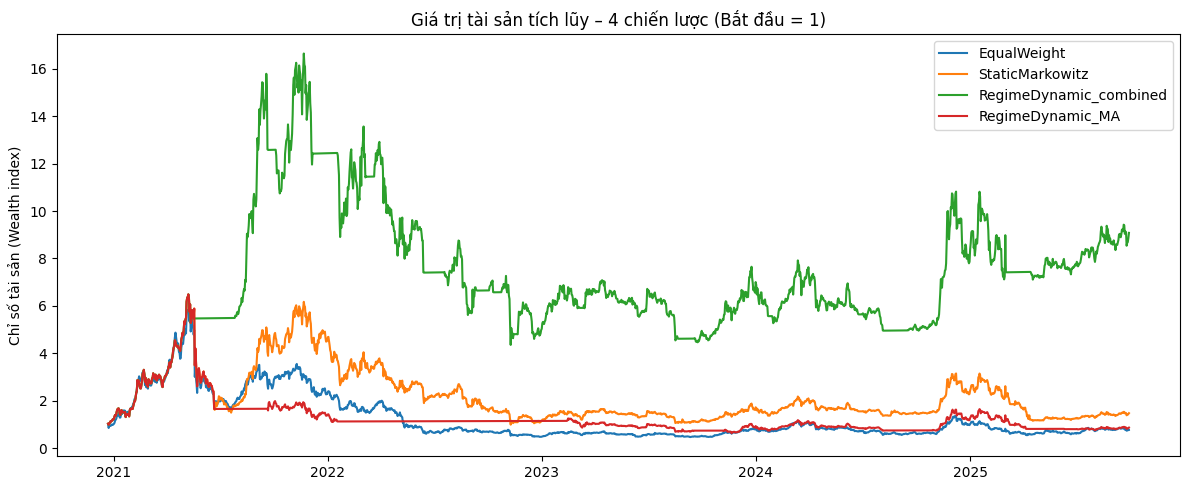

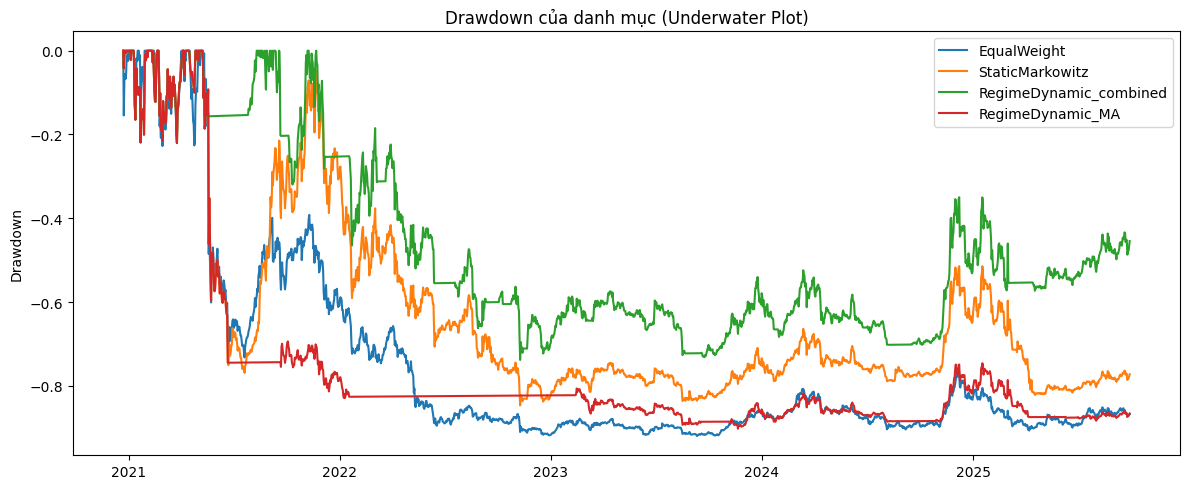

In [9]:
# Plots – Tài sản tích lũy, drawdown, tỷ trọng theo regime

# 1) Tài sản tích lũy (Cumulative wealth)
cum_wealth = (1 + df_port).cumprod()

plt.figure(figsize=(12, 5))
for col in cum_wealth.columns:
    plt.plot(cum_wealth.index, cum_wealth[col], label=col)
plt.title("Giá trị tài sản tích lũy – 4 chiến lược (Bắt đầu = 1)")
plt.ylabel("Chỉ số tài sản (Wealth index)")
plt.legend()
plt.tight_layout()
plt.show()


# 2) Biểu đồ Drawdown (underwater)
plt.figure(figsize=(12, 5))
for col in df_port.columns:
    r = df_port[col].dropna()
    cum_curve = (1 + r).cumprod()
    running_max = cum_curve.cummax()
    drawdown = cum_curve / running_max - 1
    plt.plot(drawdown.index, drawdown, label=col)
plt.title("Drawdown của danh mục (Underwater Plot)")
plt.ylabel("Drawdown")
plt.legend()
plt.tight_layout()
plt.show()



In [10]:
# Cell 7: Export daily portfolio returns để tái sử dụng

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

out_file = RESULTS_DIR / "strategy_returns.csv"
df_port.to_csv(out_file, index_label="date")

print(f"Đã lưu lợi nhuận danh mục đầu tư theo 4 chiến lược vào {out_file}")
df_port.head()


Đã lưu lợi nhuận danh mục đầu tư theo 4 chiến lược vào results/strategy_returns.csv


,EqualWeight,StaticMarkowitz,RegimeDynamic_combined,RegimeDynamic_MA
date,,,,
2020-12-22 00:00:00+00:00,0.007104,0.033940,0.033940,0.033940
2020-12-23 00:00:00+00:00,-0.154500,-0.042255,-0.042255,-0.042255
2020-12-24 00:00:00+00:00,0.102680,0.040654,0.040654,0.040654
2020-12-25 00:00:00+00:00,0.012846,0.034295,0.034295,0.034295
2020-12-26 00:00:00+00:00,-0.012243,0.058569,0.058569,0.058569


In [11]:
# Bảng Trọng số Trung bình theo Chiến lược và Trạng thái
from IPython.display import display

MSM_BULL_VALUE = 1
MSM_BEAR_VALUE = 0

# Tạo DataFrame weights tại các ngày rebalance
weights_combined_rebal_df = pd.DataFrame(
    weights_regime_combined_hist,
    index=rebalance_dates,
    columns=asset_cols
).sort_index()

weights_ma_rebal_df = pd.DataFrame(
    weights_regime_ma_hist,
    index=rebalance_dates,
    columns=asset_cols
).sort_index()

weights_static_rebal_df = pd.DataFrame(
    weights_static_hist,
    index=rebalance_dates,
    columns=asset_cols
).sort_index()

# Lấy regime tại các ngày rebalance (không phải hàng ngày)
reg_combined_rebal = regimes_combined.reindex(rebalance_dates)
reg_ma_rebal = regimes_ma.reindex(rebalance_dates)

# Tạo mask Bull/Bear chỉ tại ngày rebalance
mask_combined_bull = reg_combined_rebal == MSM_BULL_VALUE
mask_combined_bear = reg_combined_rebal == MSM_BEAR_VALUE
mask_ma_bull = reg_ma_rebal == 1

# Tính trọng số trung bình
# 1) Static Markowitz – trung bình toàn bộ giai đoạn rebalance
static_avg = weights_static_rebal_df.mean()

# 2) Combined Bull – trung bình weights khi rebalance trong trạng thái Bull
combined_bull_avg = weights_combined_rebal_df[mask_combined_bull].mean()

# 3) Combined Bear – trung bình weights khi rebalance trong trạng thái Bear
combined_bear_avg = weights_combined_rebal_df[mask_combined_bear].mean()

# 4) MA Bull – trung bình weights khi rebalance trong trạng thái Bull
ma_bull_avg = weights_ma_rebal_df[mask_ma_bull].mean()

# Ghép thành một bảng
summary_weights = pd.DataFrame({
    "Static Markowitz": static_avg,
    "Combined Bull": combined_bull_avg,
    "Combined Bear": combined_bear_avg,
    "MA Bull": ma_bull_avg
})

# Đổi sang %
summary_weights_pct = (summary_weights * 100).round(1)
summary_weights_pct.index.name = "Tài sản"

print("Trọng số Trung bình của Danh mục Tối ưu theo Chiến lược và Trạng thái")
display(summary_weights_pct)

# In thêm số lần rebalance theo mỗi trạng thái để kiểm tra
print(f"\nSố lần rebalance:")
print(f"Combined Bull: {mask_combined_bull.sum()} lần")
print(f"Combined Bear: {mask_combined_bear.sum()} lần")
print(f"MA Bull: {mask_ma_bull.sum()} lần")

Trọng số Trung bình của Danh mục Tối ưu theo Chiến lược và Trạng thái


,Static Markowitz,Combined Bull,Combined Bear,MA Bull
Tài sản,,,,
ADA_USDT,1.4,1.7,0.0,2.2
ATOM_USDT,3.3,2.1,0.0,0.2
AVAX_USDT,6.5,5.8,0.0,8.7
BCH_USDT,4.2,4.0,0.0,5.9
BNB_USDT,7.4,8.1,0.0,12.7
BTC_USDT,9.6,11.6,0.0,12.1
DOGE_USDT,4.9,4.8,0.0,4.4
DOT_USDT,0.5,0.6,0.0,0.5
EOS_USDT,1.1,1.0,0.0,3.8



Số lần rebalance:
Combined Bull: 201 lần
Combined Bear: 48 lần
MA Bull: 156 lần


In [12]:


def calculate_sharpe(returns, risk_free=0):
    mean_ret = np.mean(returns)
    std_dev = np.std(returns)
    if std_dev == 0:
        return 0
    return (mean_ret - risk_free) / std_dev

def bootstrap_sharpe_diff(returns_strategy_A, returns_strategy_B, n_bootstrap=10000):
    """
    Kiểm định giả thuyết H0: Sharpe(A) = Sharpe(B)
    Sử dụng phương pháp Bootstrap.
    returns_strategy_A: Chuỗi lợi suất (series) của chiến lược Combined
    returns_strategy_B: Chuỗi lợi suất (series) của chiến lược Static hoặc 1/N
    """
    # 1. Tính Sharpe thực tế
    sharpe_A = calculate_sharpe(returns_strategy_A)
    sharpe_B = calculate_sharpe(returns_strategy_B)
    diff_real = sharpe_A - sharpe_B
    
    # 2. Bootstrap
    combined = pd.concat([returns_strategy_A, returns_strategy_B], axis=1).dropna()
    n = len(combined)
    diffs_boot = []
    
    for _ in range(n_bootstrap):
        # Lấy mẫu lặp lại
        sample_idx = np.random.choice(n, n, replace=True)
        sample = combined.iloc[sample_idx]
        
        s_A = calculate_sharpe(sample.iloc[:, 0])
        s_B = calculate_sharpe(sample.iloc[:, 1])
        diffs_boot.append(s_A - s_B)
        
    diffs_boot = np.array(diffs_boot)
    
    # 3. Tính p-value
    # H0: diff = 0. Kiểm định 1 phía (A > B)
    # P-value là tỷ lệ số lần bootstrap mà tại đó sự khác biệt <= 0 (nếu diff_real > 0)
    p_value = np.sum(diffs_boot - np.mean(diffs_boot) + diff_real <= 0) / n_bootstrap
    
    return sharpe_A, sharpe_B, diff_real, p_value

sharpe_A, sharpe_B, diff, p_val = bootstrap_sharpe_diff(df_port['RegimeDynamic_combined'], df_port['EqualWeight'])
print(f"P-value: {p_val}")
# p_val < 0.05 => Sự vượt trội là có ý nghĩa thống kê.

P-value: 0.032
